# Logistic Regression Visualization & From-Scratch Implementation

This notebook recreates the decision boundary plot exactly as in the provided figure and adds a manual implementation for educational purposes.

In [ ]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from ipywidgets import interact, FloatSlider, IntSlider


## 1. Visualization with scikit-learn

In [ ]:
def plot_logistic(C=1.0, n_samples=50, seed=0):
    # Generate two Gaussian blobs
    np.random.seed(seed)
    cov = [[1, 0.75], [0.75, 1]]
    X1 = np.random.multivariate_normal([0, 0], cov, n_samples)
    X2 = np.random.multivariate_normal([1.5, 1.5], cov, n_samples)
    X = np.vstack((X1, X2))
    y = np.hstack((np.zeros(n_samples), np.ones(n_samples)))
    
    # Fit logistic regression
    model = LogisticRegression(C=C, solver='lbfgs')
    model.fit(X, y)
    
    # Meshgrid for decision surface
    h = .02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = model.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
    Z = Z.reshape(xx.shape)
    
    # Plot
    plt.figure(figsize=(6, 6))
    plt.contourf(xx, yy, Z, cmap='viridis', alpha=0.9)
    plt.scatter(X[y==0][:, 0], X[y==0][:, 1], c='black', edgecolors='white', label='Class 0')
    plt.scatter(X[y==1][:, 0], X[y==1][:, 1], c='red', edgecolors='white', label='Class 1')
    plt.title(f'Logistic Regression (C={C}, samples/class={n_samples}, seed={seed})')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.legend()
    plt.colorbar(label='P(class=1)')
    plt.show()


In [9]:
interact(
    plot_logistic,
    C=FloatSlider(min=0.01, max=10.0, step=0.01, value=1.0, description='C'),
    n_samples=IntSlider(min=10, max=200, step=10, value=50, description='Samples'),
    seed=IntSlider(min=0, max=100, step=1, value=0, description='Seed'),
)


interactive(children=(FloatSlider(value=1.0, description='C', max=10.0, min=0.01, step=0.01), IntSlider(value=…

<function __main__.plot_logistic(C=1.0, n_samples=50, seed=0)>

## 2. From-scratch Implementation

Iteration    0 - Loss: 0.6931
Iteration  500 - Loss: 0.4580
Iteration 1000 - Loss: 0.4579
Iteration 1500 - Loss: 0.4579
Iteration 2000 - Loss: 0.4579
Iteration 2500 - Loss: 0.4579
Iteration 3000 - Loss: 0.4579
Iteration 3500 - Loss: 0.4579
Iteration 4000 - Loss: 0.4579
Iteration 4500 - Loss: 0.4579


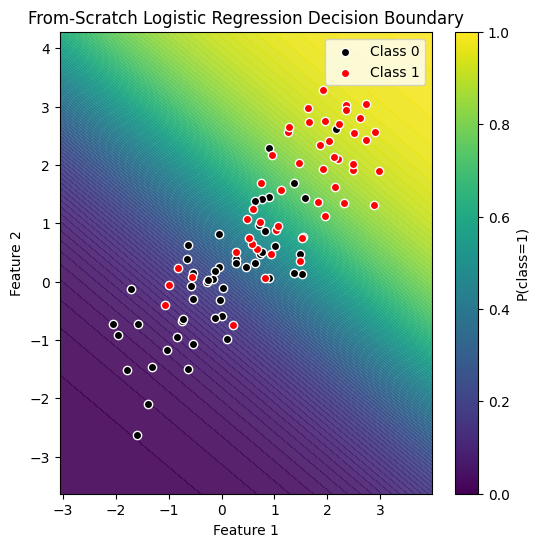

In [12]:
# ----------------------------
# 1. Helper functions
# ----------------------------

def sigmoid(z):
    """
    Compute the sigmoid activation.
    σ(z) = 1 / (1 + exp(-z))
    """
    return 1 / (1 + np.exp(-z))

def cross_entropy_loss(y_true, y_pred):
    """
    Compute the binary cross-entropy loss.
    L = -[ y*log(p) + (1-y)*log(1-p) ]
    """
    # Clip predictions to avoid log(0)
    eps = 1e-15
    p = np.clip(y_pred, eps, 1 - eps)
    return -np.mean(y_true * np.log(p) + (1 - y_true) * np.log(1 - p))

# ----------------------------
# 2. Data generation
# ----------------------------

np.random.seed(0)
cov = [[1, 0.75], [0.75, 1]]
n_samples = 50

# Two Gaussian clusters
X0 = np.random.multivariate_normal([0, 0], cov, n_samples)
X1 = np.random.multivariate_normal([1.5, 1.5], cov, n_samples)

# Combine into one dataset
X = np.vstack([X0, X1])          # shape (100, 2)
y = np.hstack([np.zeros(n_samples), np.ones(n_samples)])  # shape (100,)

# Add intercept term (bias) as the first column of 1s
X_bias = np.hstack([np.ones((X.shape[0], 1)), X])  # shape (100, 3)

# ----------------------------
# 3. Initialize parameters
# ----------------------------

# w[0] = bias weight, w[1:] = feature weights
w = np.zeros(X_bias.shape[1])  # shape (3,)

# ----------------------------
# 4. Training via Gradient Descent
# ----------------------------

learning_rate = 0.1
n_iterations = 5000

for i in range(n_iterations):
    # Linear combination
    z = X_bias.dot(w)                  # shape (100,)
    preds = sigmoid(z)                 # shape (100,)
    
    # Compute gradient of loss w.r.t. weights
    # dL/dw = X_bias^T · (preds - y) / N
    gradient = X_bias.T.dot(preds - y) / y.size
    
    # Update weights
    w -= learning_rate * gradient
    
    # (Optional) print loss every 500 iterations
    if i % 500 == 0:
        loss = cross_entropy_loss(y, preds)
        print(f"Iteration {i:4d} - Loss: {loss:.4f}")

# ----------------------------
# 5. Plot decision boundary
# ----------------------------

# Create a mesh grid over feature space
h = 0.02
x_min, x_max = X[:,0].min() - 1, X[:,0].max() + 1
y_min, y_max = X[:,1].min() - 1, X[:,1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

# Prepare grid for predictions (add bias term)
grid = np.c_[xx.ravel(), yy.ravel()]
grid_bias = np.hstack([np.ones((grid.shape[0],1)), grid])

# Predict probabilities on the grid
Z = sigmoid(grid_bias.dot(w)).reshape(xx.shape)

# Plot contour and data points
plt.figure(figsize=(6,6))
plt.contourf(xx, yy, Z, levels=100, cmap='viridis', alpha=0.9)
plt.scatter(X0[:,0], X0[:,1], c='black', edgecolors='white', label='Class 0')
plt.scatter(X1[:,0], X1[:,1], c='red',   edgecolors='white', label='Class 1')
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("From-Scratch Logistic Regression Decision Boundary")
plt.colorbar(label="P(class=1)")
plt.legend()
plt.show()


---
🎓 **Try this for yourself:**
- Change the **learning rate** (`lr`) and **iterations** (`n_iter`) in the scratch implementation to see how it affects convergence.
- Adjust `n_samples` or the covariance matrix to explore different data shapes.